Procesamiento de Imágenes: Operaciones de puntos
Transformaciones por pixel

In [64]:
import cv2
import numpy as np
np.seterr(over='raise')
import matplotlib.pyplot as plt

In [65]:
def contraste_brillo(imagen, contraste, brillo):
    imagen_procesada = np.zeros_like(imagen)
    h,w = imagen.shape
    for y in range(h):
        for x in range(w):
            try:
                imagen_procesada[y,x] = np.clip(contraste * imagen[y,x] + brillo, 0, 255).astype(np.uint8)
            except FloatingPointError as e:
                imagen_procesada[y,x] = 255
    return imagen_procesada

In [66]:
ruta = "img/detras1.jpeg"
imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
h,w = imagen.shape

In [67]:
imagen_procesada = contraste_brillo(imagen, 1.2, -30)
imagenes_comparadas = np.hstack((imagen, imagen_procesada))
cv2.imshow("Comparacion", imagenes_comparadas)
cv2.waitKey(0)

-1

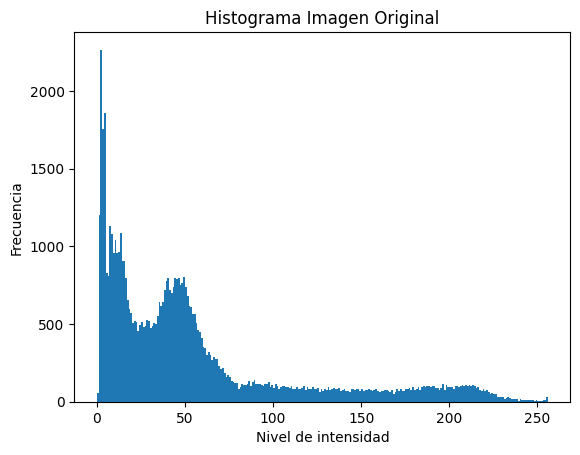

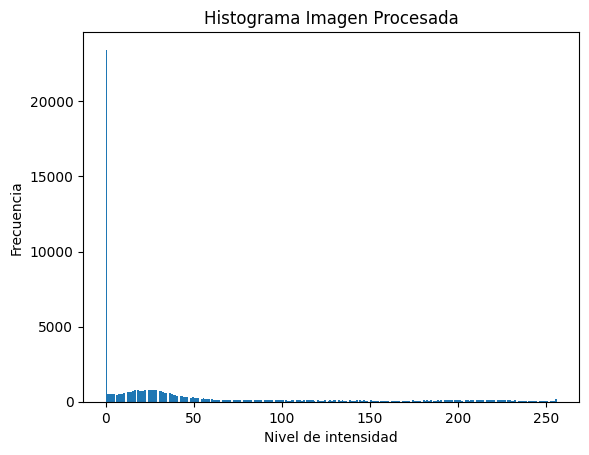

In [68]:
# Histograma imagen original
plt.figure()
plt.title("Histograma Imagen Original")
plt.hist(imagen.ravel(), bins=256, range=(0,256))
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia")
plt.show()

# Histograma imagen procesada
plt.figure()
plt.title("Histograma Imagen Procesada")
plt.hist(imagen_procesada.ravel(), bins=256, range=(0,256))
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia")
plt.show()

In [69]:
imagen_color = cv2.imread(ruta)
cv2.imshow("Imagen a color", imagen_color)
cv2.waitKey(0)

-1

In [70]:
def contraste_brillo_mat(imagen, contraste, brillo):
    imagen_p = imagen.astype(np.float32)
    return np.clip(contraste * imagen_p + brillo, 0, 255).astype(np.uint8)

In [71]:
imagen_color_procesada = contraste_brillo_mat(imagen_color, 2,-60)
cv2.imshow("Imagen a color procesada", imagen_color_procesada)
cv2.waitKey(0)

-1

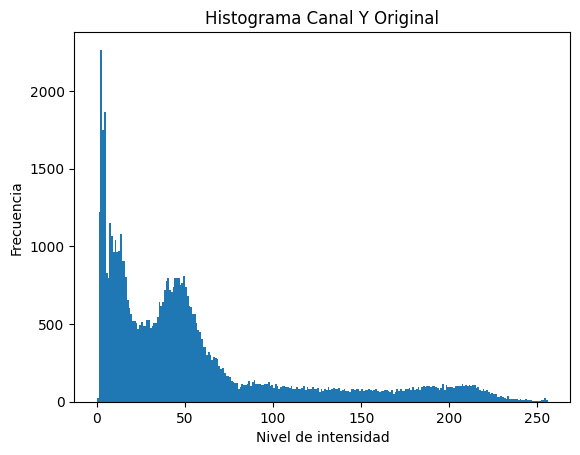

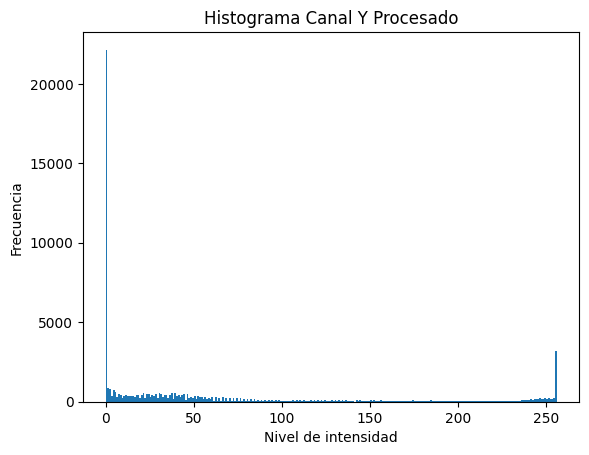

In [72]:

imagen_yuv = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2YUV)
canal_y_original = imagen_yuv[:,:,0]

imagen_yuv_proc = cv2.cvtColor(imagen_color_procesada, cv2.COLOR_BGR2YUV)
canal_y_procesado = imagen_yuv_proc[:,:,0]

# Histograma canal Y original
plt.figure()
plt.title("Histograma Canal Y Original")
plt.hist(canal_y_original.ravel(), bins=256, range=(0,256))
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia")
plt.show()

# Histograma canal Y procesado
plt.figure()
plt.title("Histograma Canal Y Procesado")
plt.hist(canal_y_procesado.ravel(), bins=256, range=(0,256))
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia")
plt.show()